Importações de Bibliotecas

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error
import io

In [31]:
dados = pd.read_csv('../Prata.csv', sep=';', encoding='utf-8', decimal=',')
dados.tail(20)

,data_Lançamento,1. Pessoal Ativo,2. Pessoal Inativo e Pensionistas,4. Indenizações por Demissão e Incentivo à Demissão,5. Decorrentes de Decisão Judicial,6. Despesas de Exercicios Anteriores,7. Inativos e Pensionistas com Recursos Vinculados,9. Receita Corrente,10. Deduções
127,08-2024,9.159031e+08,6.669900e+08,997281.2,0.0,800581.2,1.918020e+08,4.753895e+09,1.239725e+09
128,09-2024,9.654408e+08,6.675743e+08,1184812.0,0.0,1038322.4,2.182234e+08,4.603217e+09,1.194247e+09
129,10-2024,1.148392e+09,6.815468e+08,1746846.7,63971.1,2178769.0,2.227669e+08,4.623710e+09,1.437768e+09
130,11-2024,9.434185e+08,5.868478e+08,819858.6,0.0,2992505.0,2.232093e+08,4.957853e+09,1.280028e+09
131,12-2024,2.294684e+09,1.315921e+09,1166479.6,407623572.8,1215519.6,3.934379e+08,5.373587e+09,1.888398e+09
132,01-2025,1.007702e+09,6.708176e+08,NaN,NaN,NaN,2.204016e+08,5.652536e+09,1.155264e+09
133,02-2025,9.816163e+08,6.751124e+08,NaN,NaN,NaN,2.054635e+08,5.687448e+09,1.634755e+09
134,03-2025,9.609695e+08,6.769911e+08,NaN,NaN,NaN,1.961541e+08,4.727752e+09,1.293003e+09
135,04-2025,9.602988e+08,6.766460e+08,NaN,NaN,NaN,2.038257e+08,4.871807e+09,1.375843e+09
136,05-2025,9.645936e+08,6.758968e+08,NaN,NaN,NaN,2.370245e+08,5.013924e+09,1.361954e+09


In [32]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 9 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   data_Lançamento                                      147 non-null    object 
 1   1. Pessoal Ativo                                     146 non-null    float64
 2   2. Pessoal Inativo e Pensionistas                    146 non-null    float64
 3   4. Indenizações por Demissão e Incentivo à Demissão  132 non-null    float64
 4   5. Decorrentes de Decisão Judicial                   132 non-null    float64
 5   6. Despesas de Exercicios Anteriores                 132 non-null    float64
 6   7. Inativos e Pensionistas com Recursos Vinculados   146 non-null    float64
 7   9. Receita Corrente                                  135 non-null    float64
 8   10. Deduções                                         135 non-null    fl

In [33]:
dados['Data'] = pd.to_datetime(dados['data_Lançamento'], format='%m-%Y')

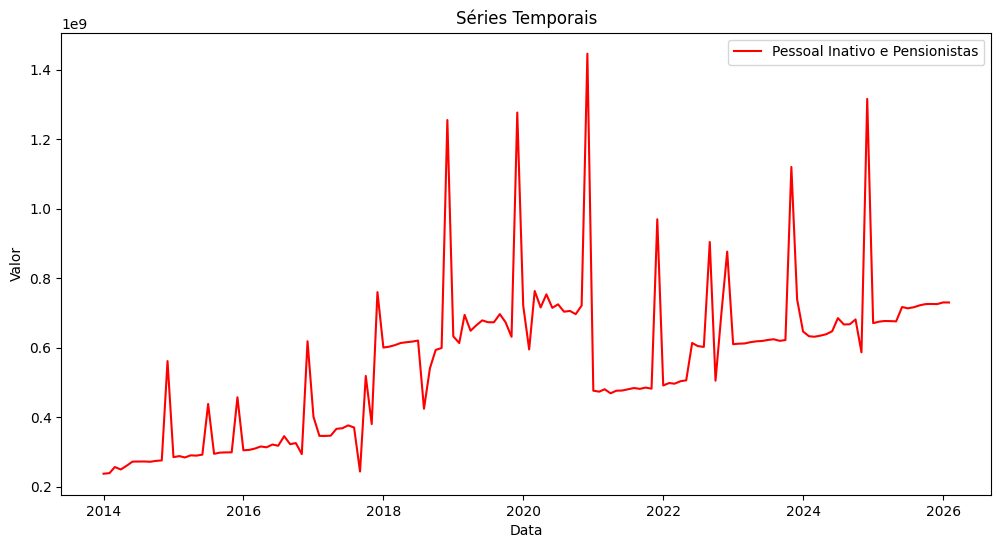

In [34]:
plt.figure(figsize=(12, 6))

plt.plot('Data', '2. Pessoal Inativo e Pensionistas', data=dados, label='Pessoal Inativo e Pensionistas',  linestyle='-', color='red')
plt.title('Séries Temporais')
plt.legend() 
plt.xlabel('Data')
plt.ylabel('Valor')
plt.show()

In [35]:
PI = pd.DataFrame(dados[['Data','2. Pessoal Inativo e Pensionistas']])
PI = PI.dropna()

Tratamento de Outlayers

In [36]:
teto = PI['2. Pessoal Inativo e Pensionistas'].quantile(0.95) # Pega o valor que representa os 95% maiores dados
# Tudo o que for maior que o teto, vira o teto. O que for menor, continua igual.
PI['2. Pessoal Inativo e Pensionistas'] = np.clip(PI['2. Pessoal Inativo e Pensionistas'], a_min=None, a_max=teto)

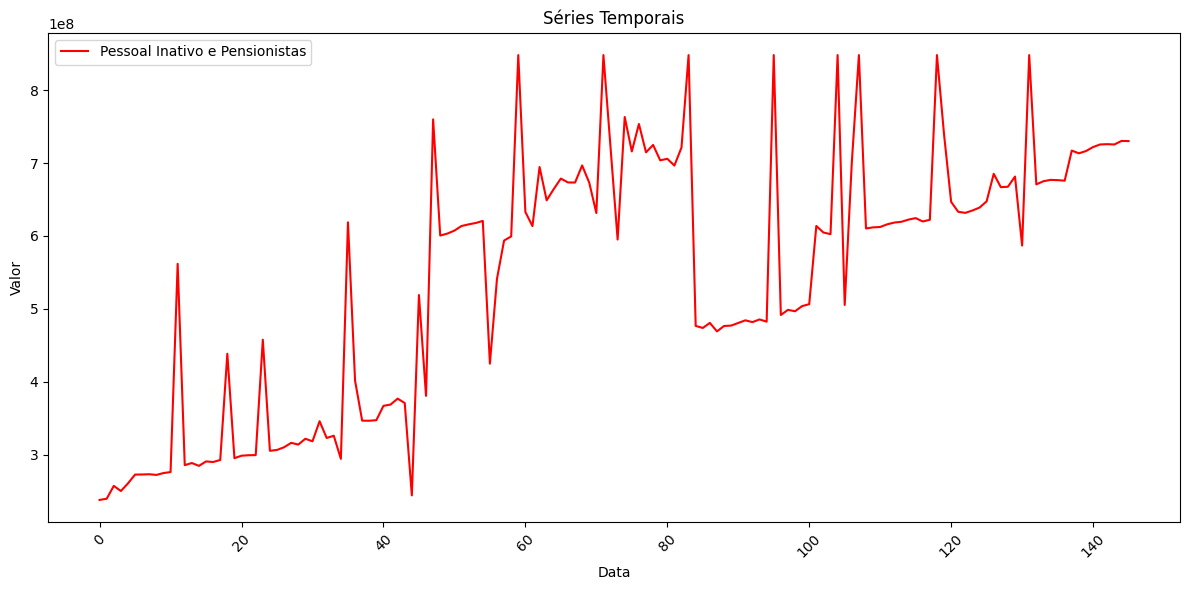

In [37]:
plt.figure(figsize=(12, 6))

plt.plot(PI.index, PI['2. Pessoal Inativo e Pensionistas'], label='Pessoal Inativo e Pensionistas', linestyle='-', color='red')
plt.title('Séries Temporais')
plt.legend()
plt.xlabel('Data')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Gráficos ACF e PACF: Pessoal Ativo

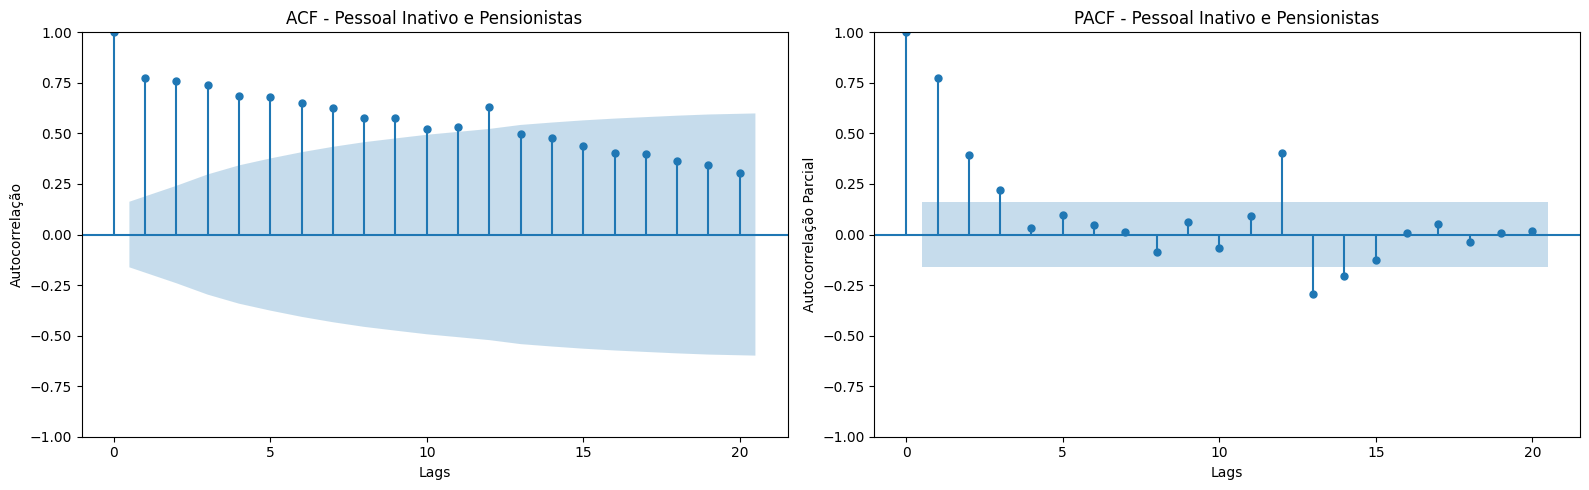

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(PI['2. Pessoal Inativo e Pensionistas'], ax=axes[0], lags=20)
axes[0].set_title('ACF - Pessoal Inativo e Pensionistas')
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Autocorrelação')  
plot_pacf(PI['2. Pessoal Inativo e Pensionistas'], ax=axes[1], lags=20)
axes[1].set_title('PACF - Pessoal Inativo e Pensionistas')   
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Autocorrelação Parcial')
plt.tight_layout()
plt.show()    


Crianção de Lags

In [39]:
PI.set_index('Data', inplace=True)
for i in range(1, 13):
    PI[f'Lag {i}'] = PI['2. Pessoal Inativo e Pensionistas'].shift(i)
PI.dropna(inplace=True)

In [40]:
#PA.reset_index(drop=True, inplace=True)
PI.head()

,2. Pessoal Inativo e Pensionistas,Lag 1,Lag 2,Lag 3,Lag 4,Lag 5,Lag 6,Lag 7,Lag 8,Lag 9,Lag 10,Lag 11,Lag 12
Data,,,,,,,,,,,,,
2015-01-01,285404693.3,561724832.4,275939680.5,274547187.9,272021647.2,272946445.7,272611127.9,272489857.3,260413679.0,249888179.7,256959731.4,239350976.8,237679792.2
2015-02-01,288368226.1,285404693.3,561724832.4,275939680.5,274547187.9,272021647.2,272946445.7,272611127.9,272489857.3,260413679.0,249888179.7,256959731.4,239350976.8
2015-03-01,284437516.3,288368226.1,285404693.3,561724832.4,275939680.5,274547187.9,272021647.2,272946445.7,272611127.9,272489857.3,260413679.0,249888179.7,256959731.4
2015-04-01,290544529.8,284437516.3,288368226.1,285404693.3,561724832.4,275939680.5,274547187.9,272021647.2,272946445.7,272611127.9,272489857.3,260413679.0,249888179.7
2015-05-01,289738065.9,290544529.8,284437516.3,288368226.1,285404693.3,561724832.4,275939680.5,274547187.9,272021647.2,272946445.7,272611127.9,272489857.3,260413679.0


In [41]:
PI.tail(10)

,2. Pessoal Inativo e Pensionistas,Lag 1,Lag 2,Lag 3,Lag 4,Lag 5,Lag 6,Lag 7,Lag 8,Lag 9,Lag 10,Lag 11,Lag 12
Data,,,,,,,,,,,,,
2025-05-01,6.758968e+08,6.766460e+08,6.769911e+08,6.751124e+08,6.708176e+08,8.482936e+08,5.868478e+08,6.815468e+08,6.675743e+08,6.669900e+08,6.853145e+08,6.475093e+08,6.389363e+08
2025-06-01,7.172346e+08,6.758968e+08,6.766460e+08,6.769911e+08,6.751124e+08,6.708176e+08,8.482936e+08,5.868478e+08,6.815468e+08,6.675743e+08,6.669900e+08,6.853145e+08,6.475093e+08
2025-07-01,7.134307e+08,7.172346e+08,6.758968e+08,6.766460e+08,6.769911e+08,6.751124e+08,6.708176e+08,8.482936e+08,5.868478e+08,6.815468e+08,6.675743e+08,6.669900e+08,6.853145e+08
2025-08-01,7.165844e+08,7.134307e+08,7.172346e+08,6.758968e+08,6.766460e+08,6.769911e+08,6.751124e+08,6.708176e+08,8.482936e+08,5.868478e+08,6.815468e+08,6.675743e+08,6.669900e+08
2025-09-01,7.220335e+08,7.165844e+08,7.134307e+08,7.172346e+08,6.758968e+08,6.766460e+08,6.769911e+08,6.751124e+08,6.708176e+08,8.482936e+08,5.868478e+08,6.815468e+08,6.675743e+08
2025-10-01,7.256230e+08,7.220335e+08,7.165844e+08,7.134307e+08,7.172346e+08,6.758968e+08,6.766460e+08,6.769911e+08,6.751124e+08,6.708176e+08,8.482936e+08,5.868478e+08,6.815468e+08
2025-11-01,7.260036e+08,7.256230e+08,7.220335e+08,7.165844e+08,7.134307e+08,7.172346e+08,6.758968e+08,6.766460e+08,6.769911e+08,6.751124e+08,6.708176e+08,8.482936e+08,5.868478e+08
2025-12-01,7.255855e+08,7.260036e+08,7.256230e+08,7.220335e+08,7.165844e+08,7.134307e+08,7.172346e+08,6.758968e+08,6.766460e+08,6.769911e+08,6.751124e+08,6.708176e+08,8.482936e+08
2026-01-01,7.304234e+08,7.255855e+08,7.260036e+08,7.256230e+08,7.220335e+08,7.165844e+08,7.134307e+08,7.172346e+08,6.758968e+08,6.766460e+08,6.769911e+08,6.751124e+08,6.708176e+08


Dividindo entre treino e teste

In [42]:
y = PI['2. Pessoal Inativo e Pensionistas'].values.reshape(-1, 1).astype(float)
X = PI.drop(columns=['2. Pessoal Inativo e Pensionistas']).values.astype(float)

In [43]:
X.shape, y.shape

((134, 12), (134, 1))

In [44]:
PI.index[119]

Timestamp('2024-12-01 00:00:00')

In [45]:
#Treino
X_train = X[:120]
y_train = y[:120]

#Validação
X_val = X[120:132]
y_val = y[120:132]

#Teste
X_test = X[132:]
y_test = y[132:]

In [46]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape ,X_test.shape, y_test.shape, 

((120, 12), (120, 1), (12, 12), (12, 1), (2, 12), (2, 1))

Normalizando os Dados

In [47]:
# Scaler para as Features X
#scaler_X = MinMaxScaler()
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train) #treino
X_val_scaled = scaler_X.transform(X_val)   # validação
X_test_scaled = scaler_X.transform(X_test) # teste

# Scaler para o Alvo y
#scaler_y = MinMaxScaler()
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train) #treino
y_val_scaled = scaler_y.transform(y_val)   # validação
y_test_scaled = scaler_y.transform(y_test) # teste

In [48]:
print(f"Máximo no X do treino: {X_train_scaled.max()}, Mínimo: {X_train_scaled.min()}")
print(f"Máximo no X do validação: {X_val_scaled.max()}, Mínimo: {X_val_scaled.min()}")
print(f"Máximo no X do teste: {X_test_scaled.max()}, Mínimo: {X_test_scaled.min()}")
print("---------------------------------")
print(f"Máximo no y do treino: {y_train_scaled.max()}, Mínimo: {y_train_scaled.min()}")
print(f"Máximo no y do validação: {y_val_scaled.max()}, Mínimo: {y_val_scaled.min()}")
print(f"Máximo no y do teste: {y_test_scaled.max()}, Mínimo: {y_test_scaled.min()}")


Máximo no X do treino: 1.8997918307800898, Mínimo: -1.869378627209262
Máximo no X do validação: 1.8997918307800898, Mínimo: 0.2605701734665047
Máximo no X do teste: 1.1338434970457423, Mínimo: 0.8825120026783878
---------------------------------
Máximo no y do treino: 1.8209155654882592, Mínimo: -1.8577534364730024
Máximo no y do validação: 1.0765362878799127, Mínimo: 0.7406186139274448
Máximo no y do teste: 1.1034394848145967, Mínimo: 1.102333559236869


Definição de Hiperparâmetros

In [49]:
hiperparametros = {
    'TAXA_DE_APRENDIZADO': 0.001,
    'EPOCAS': 800,
    'TAMANHO_LOTE': 12,
    'ENTRADAS': 4,
    'UNIDADES_OCULTAS': 2,
    'ATIVACAO': 'tanh',
    'RANDOM_STATE': 42,
    'VALIDACAO': (X_val_scaled, y_val_scaled),
    "DROPOUT_RATE": 0.2
    
}

In [50]:
#Construção da arquitetura

#Camada de Entrada
model_mlp = Sequential([Dense(hiperparametros['ENTRADAS'], # 64 Neurônio nesta camada (Z = W*X + b)
                                  input_shape=(X_train_scaled.shape[1],), # Quantidade de variáveis que vão entrar ( Z = w1*x1 + w2*x2 + b)
                                  activation=hiperparametros['ATIVACAO']) ]) # Especificando qual vai ser o tipo de ativação. Ex: reLu, linear, tanh, sigmoid...

#Dropout entre as camadas para evitar overfitting
#model_mlp.add(Dropout(hiperparametros['DROPOUT_RATE'])) # Adiciona uma camada de Dropout para ajudar a prevenir overfitting, desligando aleatoriamente 20% dos neurônios durante o treinamento

#Camada Oculta 1
model_mlp.add(Dense(hiperparametros['UNIDADES_OCULTAS'], activation=hiperparametros['ATIVACAO']))

#Dropout entre as camadas para evitar overfitting
#model_mlp.add(Dropout(hiperparametros['DROPOUT_RATE'])) # Adiciona uma camada de Dropout para ajudar a prevenir overfitting, desligando aleatoriamente 20% dos neurônios durante o treinamento

#Camada de Saída
model_mlp.add(Dense(1, activation='linear')) # 1 Neurônio nesta camada (Z = W*X + b) 


#Configuração
model_mlp.compile(
    optimizer=Adam(learning_rate=hiperparametros['TAXA_DE_APRENDIZADO']), #Aplicação do modelo de Gradiente descendente, usando o leanning rate proposto
    loss='mse', # Qual a função da loss. Nesse caso o mse é (Z - F(x1,x2))²
    metrics=['mae'] # Erro Médio Absoluto para termos uma métrica mais legível
)


## Define a regra de parada
parada_antecipada = EarlyStopping(
    monitor='val_loss', # Fica de olho no erro de validação
    patience=50,        # Se o erro não cair por 50 épocas seguidas, ele para
    restore_best_weights=True # Garante que você ficará com os melhores pesos encontrados
)



#Treinamento
historico = model_mlp.fit(
    X_train_scaled, y_train_scaled, #Indica quais são as bases
    epochs=hiperparametros['EPOCAS'], 
    batch_size=hiperparametros['TAMANHO_LOTE'], #O batch_size é a batelada de cada iteração (epoch) que será calculada
    validation_data=hiperparametros['VALIDACAO'], #Indica qual é a base de validação
    shuffle=False, # Manter a ordem temporal dos dados
    verbose=1, # Mude para 1 se quiser ver o log de cada época,
    callbacks=[parada_antecipada] # Early Stopping para evitar overfitting
)

Epoch 1/800


c:\Projeto Series Temporais\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.9741 - mae: 0.8276 - val_loss: 0.7470 - val_mae: 0.8347
Epoch 2/800
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.8855 - mae: 0.7837 - val_loss: 0.6461 - val_mae: 0.7713
Epoch 3/800
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8132 - mae: 0.7456 - val_loss: 0.5562 - val_mae: 0.7104
Epoch 4/800
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7501 - mae: 0.7122 - val_loss: 0.4777 - val_mae: 0.6529
Epoch 5/800
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6955 - mae: 0.6830 - val_loss: 0.4101 - val_mae: 0.5994
Epoch 6/800
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6488 - mae: 0.6568 - val_loss: 0.3524 - val_mae: 0.5500
Epoch 7/800
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6091 - mae: 0.6338 - val_loss: 0.3036 - val_mae: 0.5048
Epoch 8/800
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5758 - mae: 0.6136 - val_loss: 0.2624 - val_mae: 0.4648
Epoch 9/800
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5479 - mae: 0.

In [51]:
model_mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 4)              │            52 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197 (792.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 132 (532.00 B)

In [52]:
# get_weights() retorna uma lista: o primeiro item é a matriz de pesos (W), o segundo é o viés (b)
pesos, vies = model_mlp.get_layer(index=0).get_weights()

print(f"pesos: {pesos.flatten()} e o viés: {vies[0]:.4f}")

pesos: [ 0.13922265  0.6179185   0.28742233 -0.6350944   0.19842699  0.13862747
  0.04204047 -0.5487512  -0.2281684  -0.36005342 -0.71175337 -0.04917646
 -0.4185916  -0.42699474  0.497642   -0.34269014 -0.00141546 -0.2448103
 -0.5858873   0.36462858 -0.53261715 -0.39296126  0.14485042 -0.18546577
  0.4764673   0.305599    0.02435004 -0.1707636  -0.09354017  0.1293807
 -0.28099355  0.53622806  0.16685264  0.16036099  0.02489961 -0.14957167
 -0.1554985  -0.23917486  0.5154373   0.06248891  0.23025122  0.3856147
  0.35056236 -0.30440524 -0.5517205   0.6555016  -0.5039834   0.18242702] e o viés: -0.0108


In [53]:
#data_min = scaler_X.data_min_
#scale = scaler_X.scale_

# w = pesos / scale (scale is the range: 1/(max - min))
#w = pesos / scale[:, np.newaxis]
#b_raw = vies - np.dot(data_min, w)

#w_escalar = w[0][0]
#b_raw_escalar = b_raw[0]

#print(f"Pesos desnormalizados: {w.flatten()}")
#print(f"Viés desnormalizado: {b_raw_escalar:.4f}")

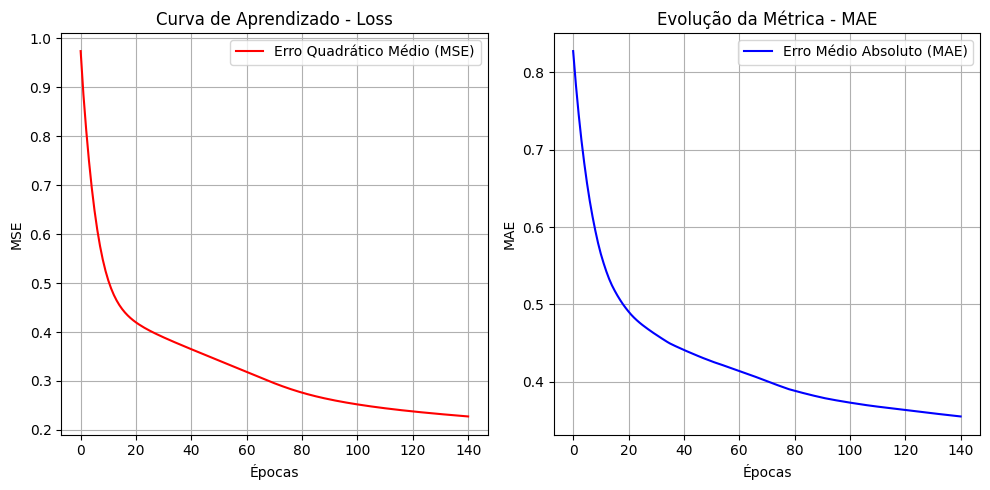

In [54]:
plt.figure(figsize=(10, 5))

# Plotando a Perda (MSE)
plt.subplot(1, 2, 1)
plt.plot(historico.history['loss'], label='Erro Quadrático Médio (MSE)', color='red')
plt.title('Curva de Aprendizado - Loss')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

# Plotando a Métrica (MAE)
plt.subplot(1, 2, 2)
plt.plot(historico.history['mae'], label='Erro Médio Absoluto (MAE)', color='blue')
plt.title('Evolução da Métrica - MAE')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [55]:
erro_simples = model_mlp.evaluate(X_test_scaled, y_test_scaled, verbose=0)[1]
print(f"Erro Médio Absoluto (Simples): {erro_simples:.2f}\n")

Erro Médio Absoluto (Simples): 0.12



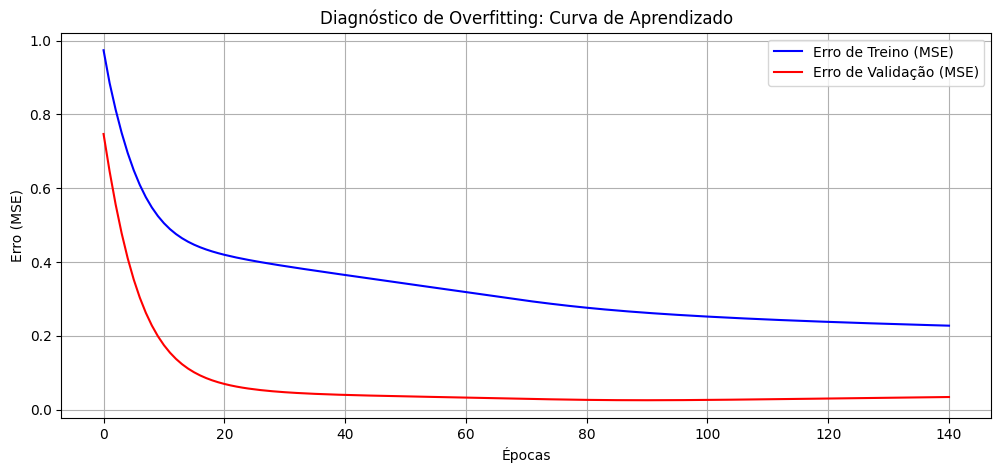

In [56]:
# Criando a figura para as curvas de perda (Loss)
plt.figure(figsize=(12, 5))

# Plotando a Perda de Treino
plt.plot(historico.history['loss'], label='Erro de Treino (MSE)', color='blue')

# Plotando a Perda de Validação (se você passou validation_data no fit)
if 'val_loss' in historico.history:
    plt.plot(historico.history['val_loss'], label='Erro de Validação (MSE)', color='red')

plt.title('Diagnóstico de Overfitting: Curva de Aprendizado')
plt.xlabel('Épocas')
plt.ylabel('Erro (MSE)')
plt.legend()
plt.grid(True)
plt.show()

O earlystop evitou que o erro aumentasse de acordo com as epocas seguintes. Porém, o GAP entre os conjuntos de teste e validação indica um overfeting pois o conjunto de teste FALHOU em aplicar de forma acertiva no conjunto de validação. 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
--- Desempenho no Teste (Escala Original) ---
MAE (Erro Médio Absoluto): 18896290.9300
RMSE (Raiz do Erro Quadrático): 18960251.3455


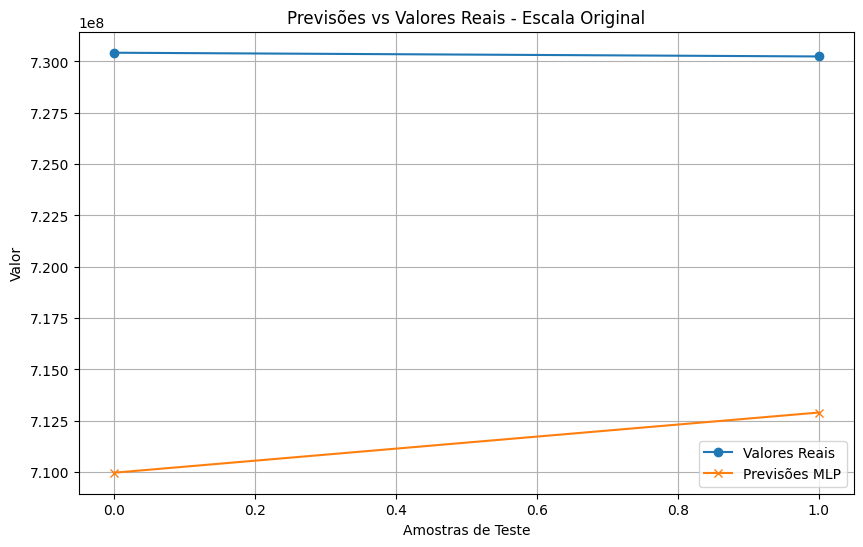

In [57]:
# Fazer as previsões usando o X de teste normalizado
y_pred_scaled = model_mlp.predict(X_test_scaled)

# Desfazer a normalização das previsões e dos valores reais
y_pred_original = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test_scaled) # ou apenas use o seu y_test original

# Calcular as métricas na escala real do negócio
mae_real = mean_absolute_error(y_test_original, y_pred_original)
mse_real = mean_squared_error(y_test_original, y_pred_original)
rmse_real = np.sqrt(mse_real)

print(f"--- Desempenho no Teste (Escala Original) ---")
print(f"MAE (Erro Médio Absoluto): {mae_real:.4f}")
print(f"RMSE (Raiz do Erro Quadrático): {rmse_real:.4f}")

# 4. Plotar o gráfico com os dados reais
plt.figure(figsize=(10, 6))
plt.plot(y_test_original, label='Valores Reais', marker='o', color='tab:blue')
plt.plot(y_pred_original, label='Previsões MLP', marker='x', color='tab:orange')

plt.title('Previsões vs Valores Reais - Escala Original')
plt.xlabel('Amostras de Teste')
plt.ylabel('Valor') # Aqui os valores estarão na sua grandeza original (R$, quantidades, etc.)
plt.legend()
plt.grid(True)
plt.show()

--- ANO DE 2026 COMPLETO (TESTE + RECURSIVO) ---
Jan/2026: 709,971,072.00 (Teste)
Fev/2026: 712,901,504.00 (Teste)
Mar/2026: 712,901,504.00 (Recursivo)
Abr/2026: 713,308,416.00 (Recursivo)
Mai/2026: 713,625,920.00 (Recursivo)
Jun/2026: 712,275,200.00 (Recursivo)
Jul/2026: 708,139,968.00 (Recursivo)
Ago/2026: 711,275,776.00 (Recursivo)
Set/2026: 705,888,256.00 (Recursivo)
Out/2026: 705,247,104.00 (Recursivo)
Nov/2026: 705,526,784.00 (Recursivo)
Dez/2026: 705,696,192.00 (Recursivo)


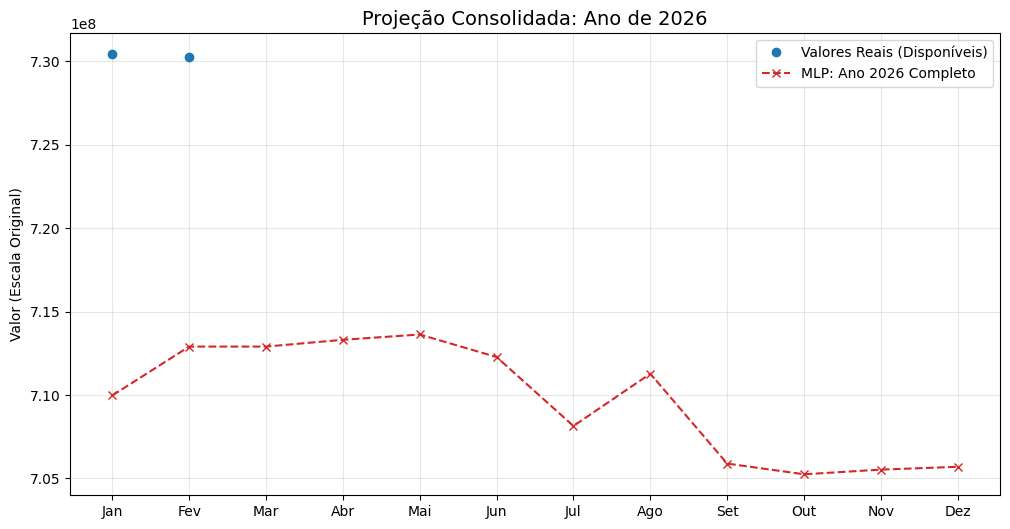

In [58]:
# --- 1. DEFINIÇÃO DO PONTO DE PARTIDA ---
# y_pred_scaled contém as previsões que o modelo já fez para o período de teste (Jan, Fev, Mar)
previsoes_existentes = list(y_pred_scaled.flatten()) 
passos_restantes = 12 - len(previsoes_existentes) # Quantos meses faltam para fechar o ano

n_lags = model_mlp.input_shape[1]
# A semente para o futuro precisa ser a última janela de "Teste" que o modelo previu
ultima_sequencia = X_test_scaled[-1].copy()

# --- 2. LOOP RECURSIVO PARA OS MESES FALTANTES ---
for _ in range(passos_restantes):
    # Prevemos o próximo mês baseado na última sequência
    pred_scaled = model_mlp.predict(ultima_sequencia.reshape(1, n_lags), verbose=0)[0, 0]
    previsoes_existentes.append(pred_scaled)
    
    # Atualizamos a janela para a próxima iteração
    ultima_sequencia = np.append(ultima_sequencia[1:], pred_scaled)

# --- 3. CONSOLIDAÇÃO E REVERSÃO DE ESCALA ---
# Agora 'previsoes_existentes' tem exatamente 12 valores (O ano de 2026 completo)
ano_2026_scaled = np.array(previsoes_existentes).reshape(-1, 1)
ano_2026_original = scaler_y.inverse_transform(ano_2026_scaled)

print(f"--- ANO DE 2026 COMPLETO (TESTE + RECURSIVO) ---")
meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
for i, valor in enumerate(ano_2026_original):
    tipo = "Teste" if i < len(y_pred_scaled) else "Recursivo"
    print(f"{meses[i]}/2026: {valor[0]:,.2f} ({tipo})")

# --- 4. VISUALIZAÇÃO ---
plt.figure(figsize=(12, 6))

# Eixo X para os 12 meses
eixo_2026 = np.arange(1, 13)

# Plotamos o real disponível (os pontos que você já tinha no teste)
plt.plot(eixo_2026[:len(y_test_original)], y_test_original, 
         label='Valores Reais (Disponíveis)', marker='o', color='tab:blue', ls='None')

# Plotamos a linha completa da MLP (3 meses de teste + 9 meses projetados)
plt.plot(eixo_2026, ano_2026_original, 
         label='MLP: Ano 2026 Completo', marker='x', linestyle='--', color='tab:red')

plt.title('Projeção Consolidada: Ano de 2026', fontsize=14)
plt.xticks(eixo_2026, meses)
plt.ylabel('Valor (Escala Original)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()